In [34]:
import pickle
from pathlib import Path

MODEL_PATH = Path("../models/som_model_200Hz_ver9_ppg_center.pkl")  

with open(MODEL_PATH, "rb") as f:
    som_model = pickle.load(f)

print("Modell laddad")
print(som_model.get_summary())

Modell laddad
{'x': 30, 'y': 30, 'input_len': 3, 'sigma': 6, 'learning_rate': 0.1, 'decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'topology': 'rectangular', 'activation_distance': 'euclidean', 'sigma_decay_function': 'asymptotic_decay', 'random_seed': 42}


In [35]:
import pandas as pd

df_test = pd.read_csv("test_features_windows_ppg_centroid/features_49_60_ALL_WINDOWS_PPG_centroid.csv")

print("Rows:", len(df_test))
df_test.head()

Rows: 27106


,HR,HRV_RMSSD,RR_diff_std,HRV_SDNN,RR_mean,RR_std,RR_min,RR_max,RR_count,RR_quality,RR_valid,SCR_Rate,participant,time_sec,EDA_Tonic_log,EDA_Phasic_log
0,81.723098,44.020880,43.967748,36.626988,747.368421,36.141841,670.0,835.0,38,1.0,1,0.064539,49,0,6.0,0.586243
1,81.877186,42.914644,42.882268,35.749978,747.875000,35.300274,670.0,835.0,40,1.0,1,0.064539,49,1,6.0,1.197047
2,80.411177,44.325428,44.169225,34.637315,744.500000,34.201608,670.0,835.0,40,1.0,1,0.032790,49,2,6.0,0.984237
3,80.665304,46.305839,46.305662,32.096609,743.250000,31.692862,670.0,790.0,40,1.0,1,0.032790,49,3,6.0,0.465884
4,80.857473,47.203019,47.155163,32.317971,740.731707,31.921416,670.0,790.0,41,1.0,1,0.064539,49,4,6.0,0.016760


In [36]:
features = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN"
]

# Kontroll att features finns
missing = [f for f in features if f not in df_test.columns]
assert len(missing) == 0, f"Saknade features: {missing}"

df_test[features].describe()

,HR,HRV_RMSSD,HRV_SDNN
count,27106.000000,27106.000000,27106.000000
mean,82.381346,48.866112,56.741444
std,11.058465,15.813996,22.768464
min,59.006325,9.419421,9.764864
25%,74.079580,36.425668,40.581940
50%,81.351994,50.233945,53.111949
75%,88.630773,61.222212,70.038786
max,129.457980,100.417398,171.722745


In [37]:
df_test_clean = df_test.dropna(subset=features).copy()

print("Före:", len(df_test))
print("Efter:", len(df_test_clean))

Före: 27106
Efter: 27106


In [38]:
print(df_test_clean[features].describe())

                 HR     HRV_RMSSD      HRV_SDNN
count  27106.000000  27106.000000  27106.000000
mean      82.381346     48.866112     56.741444
std       11.058465     15.813996     22.768464
min       59.006325      9.419421      9.764864
25%       74.079580     36.425668     40.581940
50%       81.351994     50.233945     53.111949
75%       88.630773     61.222212     70.038786
max      129.457980    100.417398    171.722745


In [39]:
import numpy as np

X_test = df_test_clean[features]

print("Har NaN:\n", X_test.isna().sum())

# 🔒 Feature consistency (viktigt!)
assert list(X_test.columns) == list(som_model.scaler.feature_names_in_)

Har NaN:
 HR           0
HRV_RMSSD    0
HRV_SDNN     0
dtype: int64


In [40]:
X_test_scaled = pd.DataFrame(
    som_model.scaler.transform(X_test),
    columns=features,
    index=X_test.index
)

print("Shape:", X_test_scaled.shape)

Shape: (27106, 3)


In [41]:
print(X_test_scaled.describe())
print("\nVariance:\n", X_test_scaled.var())

                 HR     HRV_RMSSD      HRV_SDNN
count  27106.000000  27106.000000  27106.000000
mean       0.290416      0.442066      0.290273
std        0.107840      0.171159      0.141934
min        0.062467      0.015125     -0.002568
25%        0.209459      0.307420      0.189538
50%        0.280378      0.456870      0.267648
75%        0.351360      0.575799      0.373166
max        0.749500      1.000017      1.007042

Variance:
 HR           0.011630
HRV_RMSSD    0.029295
HRV_SDNN     0.020145
dtype: float64


In function predict_cluster send df **WITHOUT** scaling

In [42]:
pred_clusters = som_model.predict_cluster(X_test)

# Säkerhet
assert len(pred_clusters) == len(df_test_clean)

df_test_clean["cluster"] = pred_clusters

print("Clusters tilldelade ✅")

🔍 INPUT (first 5 rows):
          HR  HRV_RMSSD   HRV_SDNN
0  81.723098  44.020880  36.626988
1  81.877186  42.914644  35.749978
2  80.411177  44.325428  34.637315
3  80.665304  46.305839  32.096609
4  80.857473  47.203019  32.317971
🔍 INPUT range:
min: HR           59.006325
HRV_RMSSD     9.419421
HRV_SDNN      9.764864
dtype: float64
max: HR           129.457980
HRV_RMSSD    100.417398
HRV_SDNN     171.722745
dtype: float64

🔍 AFTER scaling (first 5 rows):
[[0.28399725 0.38962466 0.16488418]
 [0.28549989 0.37765161 0.15941709]
 [0.2712036  0.39292086 0.15248099]
 [0.27368182 0.41435531 0.13664278]
 [0.27555581 0.42406569 0.1380227 ]]
🔍 AFTER scaling range:
min: -0.0025684616833052468
max: 1.0070417605687516

🔍 Unique BMUs: 807
🔍 Unique clusters: {np.int32(0), np.int32(1), np.int32(2)}
Clusters tilldelade ✅


In [43]:
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]

print("Unika BMUs:", len(set(bmus)))

Unika BMUs: 807


=== Cluster Distribution ===
cluster
0    0.434443
2    0.290083
1    0.275474
Name: proportion, dtype: float64

=== Per Participant ===
participant  cluster
49           0          0.527439
             1          0.433798
             2          0.038763
50           0          0.649826
             2          0.215592
             1          0.134582
51           1          0.810292
             0          0.189708
52           1          0.887631
             0          0.112369
53           0          0.697817
             2          0.300437
             1          0.001747
54           2          0.855013
             0          0.144987
55           2          0.783319
             0          0.216681
56           1          0.774433
             0          0.225567
57           0          0.756002
             1          0.140113
             2          0.103885
58           0          0.589065
             2          0.396384
             1          0.014550
59           0   

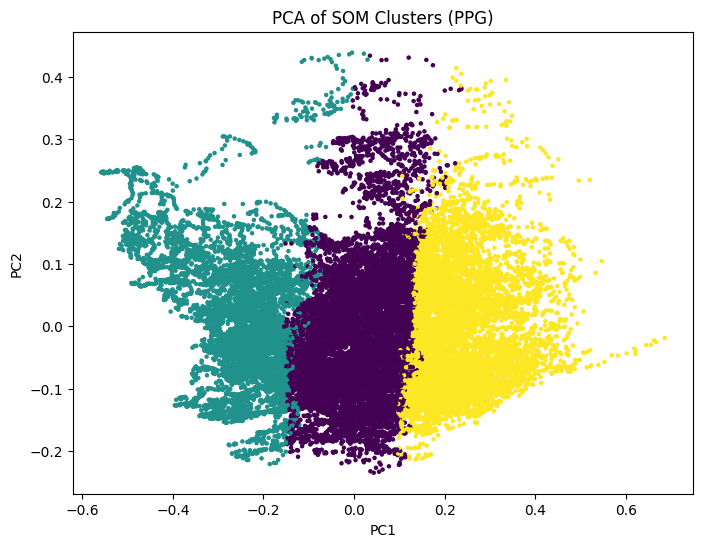


=== Cluster Interpretation ===

Cluster 0
HR           81.639391
HRV_RMSSD    50.513643
HRV_SDNN     54.124618
Name: 0, dtype: float64

Cluster 1
HR           87.693174
HRV_RMSSD    29.173549
HRV_SDNN     35.867273
Name: 1, dtype: float64

Cluster 2
HR           78.448222
HRV_RMSSD    65.099490
HRV_SDNN     80.483425
Name: 2, dtype: float64

Silhouette (neurons): 0.3718426474075172


In [44]:


import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Klusterfördelning
print("=== Cluster Distribution ===")
print(df_test_clean["cluster"].value_counts(normalize=True))

# 2. Per participant
print("\n=== Per Participant ===")
print(df_test_clean.groupby("participant")["cluster"].value_counts(normalize=True))

# 3. Kluster means
print("\n=== Cluster Means ===")
cluster_means = df_test_clean.groupby("cluster")[features].mean()
print(cluster_means)

# 4. Kluster std
print("\n=== Cluster STD ===")
print(df_test_clean.groupby("cluster")[features].std())

# 5. Label mapping
cluster_labels = {
    0: "Active / Engagement",
    1: "Stress",
    2: "Recovery"
}

df_test_clean["cluster_label"] = df_test_clean["cluster"].map(cluster_labels)

print("\n=== Cluster Labels Distribution ===")
print(df_test_clean["cluster_label"].value_counts(normalize=True))

# 6. PCA visualisering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_test_clean["cluster"],
    s=5
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of SOM Clusters (PPG)")
plt.show()

# 7. Fysiologisk tolkning
print("\n=== Cluster Interpretation ===")
for c in sorted(df_test_clean["cluster"].unique()):
    print(f"\nCluster {c}")
    print(cluster_means.loc[c])

# 8. Silhouette (på neuroner - snabbt)
try:
    weights = som_model.som.get_weights().reshape(-1, len(features))
    labels = som_model.kmeans.labels_
    score = silhouette_score(weights, labels)
    print("\nSilhouette (neurons):", score)
except:
    print("\nSilhouette kunde inte beräknas (saknar kmeans i modellen)")

In [31]:
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]

cluster_labels = []

for bmu in bmus:
    idx = bmu[0] * som_model.som._weights.shape[1] + bmu[1]
    cluster_labels.append(som_model.kmeans.labels_[idx])

print(set(cluster_labels))

{np.int32(0), np.int32(1), np.int32(2)}


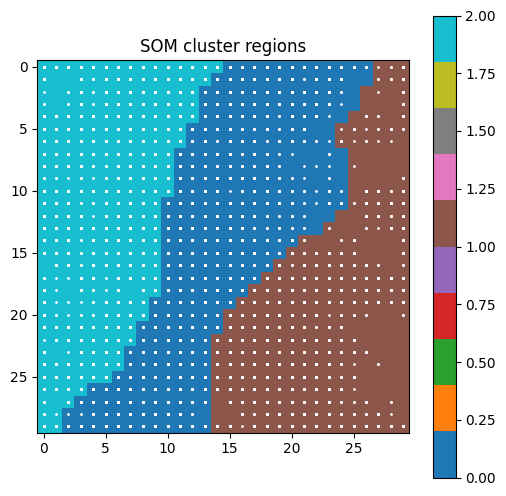

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# k-means labels över SOM grid
labels_map = som_model.kmeans.labels_.reshape(30, 30)

plt.figure(figsize=(6,6))
plt.imshow(labels_map, cmap='tab10')
plt.title("SOM cluster regions")
plt.colorbar()

# overlay dina BMUs
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]
xs = [b[0] for b in bmus]
ys = [b[1] for b in bmus]

plt.scatter(ys, xs, s=1, c='white')  # overlay
plt.show()

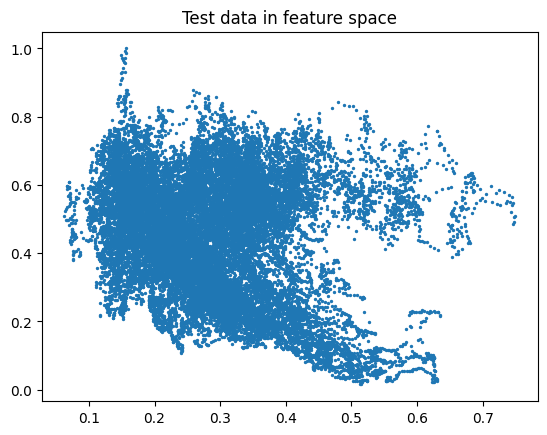

In [46]:
import matplotlib.pyplot as plt

plt.scatter(
    X_test_scaled["HR"],
    X_test_scaled["HRV_RMSSD"],
    s=2
)
plt.title("Test data in feature space")
plt.show()